In [34]:
#load all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import precision_score, recall_score, roc_auc_score



In [35]:
X_train=pd.read_csv("../output/x_train.csv")
X_test=pd.read_csv("../output/x_test.csv")
y_train=pd.read_csv("../output/y_train.csv").squeeze()
y_test=pd.read_csv("../output/y_test.csv").squeeze()

# Apply Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Test different values of K
k_values = [3, 5, 7, 9, 11, 15]
scores_of_diferent_k_values = []

# Knn forloop to test different k values
for current_k_value in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=current_k_value)
    knn_model.fit(X_train_scaled, y_train)
    y_predicted = knn_model.predict(X_test_scaled)
    # Generate probabilities for ROC-AUC
    y_probabilities_for_ROC_AUC = knn_model.predict_proba(X_test_scaled)
    
    # Calculate the metrics
    accuracy_of_the_current_k_value = accuracy_score(y_test, y_predicted)
    f1_score_of_the_current_k_value = f1_score(y_test, y_predicted, average='weighted') 
    precision_of_the_current_k_value = precision_score(y_test, y_predicted, average='weighted')
    recall_of_the_current_k_value = recall_score(y_test, y_predicted, average='weighted')
    roc_auc_of_the_current_k_value = roc_auc_score(y_test, y_probabilities_for_ROC_AUC, multi_class='ovr', average='weighted')
    
    # Print out the result of each K value
    scores_of_diferent_k_values.append((current_k_value, accuracy_of_the_current_k_value, f1_score_of_the_current_k_value, precision_of_the_current_k_value, recall_of_the_current_k_value, roc_auc_of_the_current_k_value))
    print(f"K={current_k_value} -> Accuracy: {accuracy_of_the_current_k_value:.4f}, F1: {f1_score_of_the_current_k_value:.4f}, Precision: {precision_of_the_current_k_value:.4f} Recall: {recall_of_the_current_k_value:.4f} ROC_AUC: {roc_auc_of_the_current_k_value:.4f}")

K=3 -> Accuracy: 0.5221, F1: 0.5161, Precision: 0.5137 Recall: 0.5221 ROC_AUC: 0.6858
K=5 -> Accuracy: 0.5625, F1: 0.5471, Precision: 0.5349 Recall: 0.5625 ROC_AUC: 0.7071
K=7 -> Accuracy: 0.5846, F1: 0.5648, Precision: 0.5494 Recall: 0.5846 ROC_AUC: 0.7254
K=9 -> Accuracy: 0.5368, F1: 0.5188, Precision: 0.5046 Recall: 0.5368 ROC_AUC: 0.7268
K=11 -> Accuracy: 0.5735, F1: 0.5543, Precision: 0.5402 Recall: 0.5735 ROC_AUC: 0.7434
K=15 -> Accuracy: 0.5662, F1: 0.5458, Precision: 0.5291 Recall: 0.5662 ROC_AUC: 0.7308


C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

   K_Value  Accuracy  F1-Score  Precision    Recall   ROC-AUC
0        3  0.522059  0.516088   0.513653  0.522059  0.685805
1        5  0.562500  0.547114   0.534910  0.562500  0.707080
2        7  0.584559  0.564799   0.549446  0.584559  0.725359
3        9  0.536765  0.518846   0.504649  0.536765  0.726837
4       11  0.573529  0.554323   0.540211  0.573529  0.743444
5       15  0.566176  0.545769   0.529089  0.566176  0.730752

Best K based on highest accuracy:
K_Value      7.000000
Accuracy     0.584559
F1-Score     0.564799
Precision    0.549446
Recall       0.584559
ROC-AUC      0.725359
Name: 2, dtype: float64


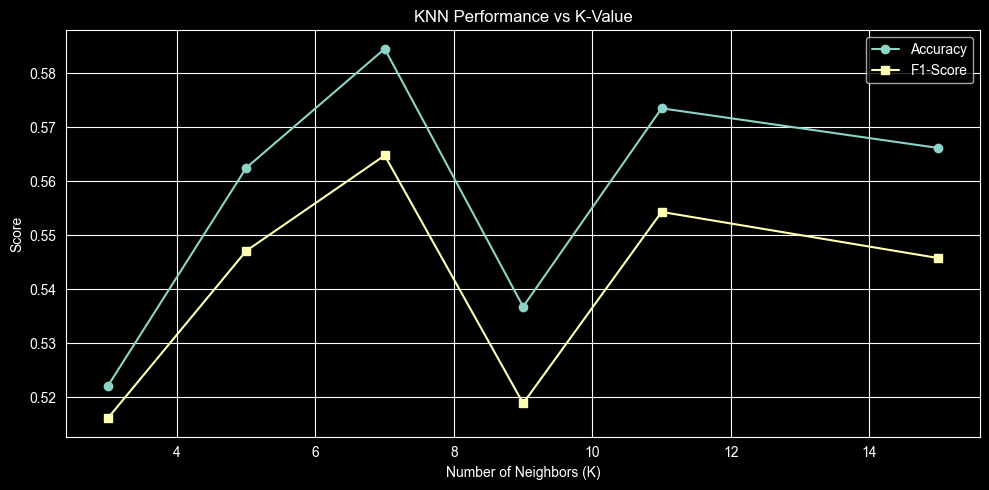


Final KNN Model Metrics:
Accuracy: 0.5845588235294118
Precision: 0.5494461931929963
Recall: 0.5845588235294118
F1-Score: 0.564798856146009
ROC-AUC: 0.7253593383540966

Classification Report:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.64      0.72      0.67       116
           6       0.56      0.60      0.58       107
           7       0.48      0.36      0.41        33
           8       0.00      0.00      0.00         3

    accuracy                           0.58       272
   macro avg       0.28      0.28      0.28       272
weighted avg       0.55      0.58      0.56       272



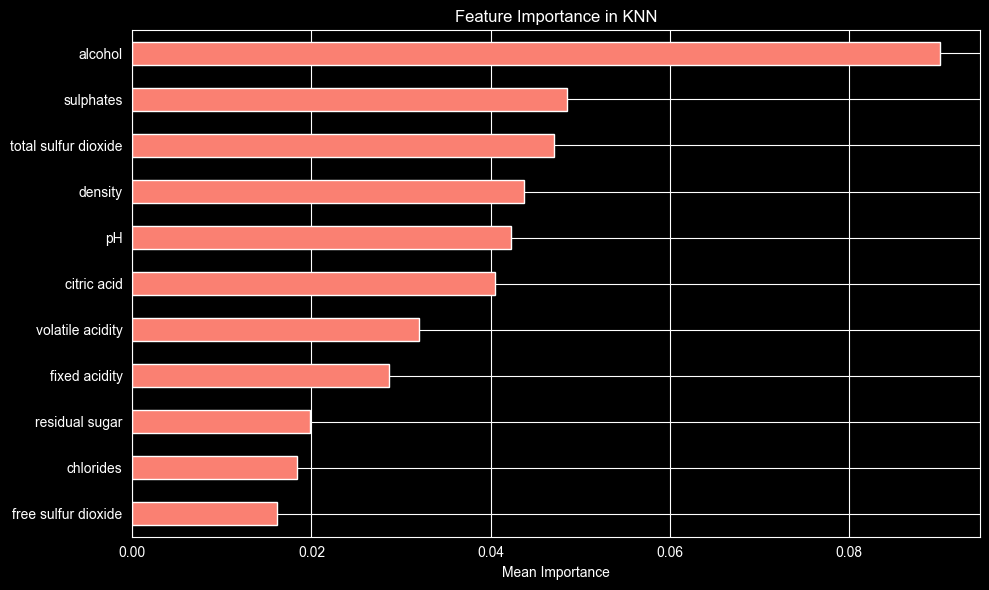


KNN final results saved successfully.


In [37]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report


column_names = ["K_Value", "Accuracy", "F1-Score", "Precision", "Recall", "ROC-AUC"]
knn_results_data_frame = pd.DataFrame(scores_of_diferent_k_values, columns=column_names)

print(knn_results_data_frame)

best_k_row = knn_results_data_frame.loc[knn_results_data_frame["Accuracy"].idxmax()]
best_k = int(best_k_row["K_Value"])

print("\nBest K based on highest accuracy:")
print(best_k_row)

plt.figure(figsize=(10, 5))
plt.plot(knn_results_data_frame["K_Value"], knn_results_data_frame["Accuracy"], marker='o', label='Accuracy')
plt.plot(knn_results_data_frame["K_Value"], knn_results_data_frame["F1-Score"], marker='s', label='F1-Score')
plt.title('KNN Performance vs K-Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train_scaled, y_train)

y_predicted_final_knn = best_knn_model.predict(X_test_scaled)
y_probabilities_final_knn = best_knn_model.predict_proba(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_predicted_final_knn)
final_precision = precision_score(y_test, y_predicted_final_knn, average='weighted', zero_division=0)
final_recall = recall_score(y_test, y_predicted_final_knn, average='weighted', zero_division=0)
final_f1 = f1_score(y_test, y_predicted_final_knn, average='weighted', zero_division=0)
final_roc_auc = roc_auc_score(y_test, y_probabilities_final_knn, multi_class='ovr', average='weighted')

print("\nFinal KNN Model Metrics:")
print("Accuracy:", final_accuracy)
print("Precision:", final_precision)
print("Recall:", final_recall)
print("F1-Score:", final_f1)
print("ROC-AUC:", final_roc_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_predicted_final_knn, zero_division=0))


result = permutation_importance(
    best_knn_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

feature_importance_in_ascending_order = pd.Series(
    result.importances_mean,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance_in_ascending_order.plot(kind='barh', color='salmon')
plt.xlabel("Mean Importance")
plt.title("Feature Importance in KNN")
plt.tight_layout()
plt.show()


knn_final_results = pd.DataFrame({
    "Model": ["KNN"],
    "Accuracy": [final_accuracy],
    "Precision": [final_precision],
    "Recall": [final_recall],
    "F1-Score": [final_f1],
    "ROC-AUC": [final_roc_auc],
    "K_Value": [best_k]
})

knn_final_results.to_csv("../output/knn_results.csv", index=False)
print("\nKNN final results saved successfully.")